# Imports

In [1]:
# Imports
import numpy as np
from numpy import nan
import pandas as pd
import matplotlib.pyplot as plt
import os
import scipy
import scipy.stats as stats
from scipy.spatial.distance import cdist
import itertools
from tqdm.auto import tqdm
import seaborn as sns
import importlib
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import bernoulli
import warnings
from GP import *
from plotter import *
from scipy.special import softmax

# Create GP world

## GP Class

In [629]:
## define the GP model
import numpy as np
import matplotlib.pyplot as plt
import scipy


class GP_world():

    def __init__(self, N, params=None):
        
        ## initialise the GP grid
        self.N = N
        x = np.arange(N)
        y = np.arange(N)
        X,Y = np.meshgrid(x,y)
        self.locations = np.column_stack([X.ravel(), Y.ravel()])

        ## set the kernel parameters
        if params is None:
            self.c = 0
            self.scale = 1.0
            self.theta = 0
            self.sigma_f = 1.0
            self.length_scale = 2
            self.periodic_length_scale = 4
            self.period = 8
            self.periodic_theta = 0
        else:
            self.c = params[0]
            self.scale = params[1]
            self.theta = params[2]
            self.sigma_f = params[3]
            self.length_scale = params[4]
            self.periodic_length_scale = params[5]
            self.period = params[6]
            self.periodic_theta = params[7]



        ## initialise the kernels
        self.K_lin = self.linear()
        self.K_lin_x = self.linear_1D(0)
        self.K_lin_y = self.linear_1D(1)
        self.K_rbf = self.rbf()
        self.K_rbf_x = self.rbf_1D(0)
        self.K_rbf_y = self.rbf_1D(1)
        self.K_periodic_x = self.periodic(0)
        self.K_periodic_y = self.periodic(1)


    #### define the kernels


    ## linear kernels

    
    # linear kernel over x,y, i.e. similarity as a function of the distance from the origin (0,0)
    def linear(self):
        dists = np.sqrt(self.locations[:, 0]**2 + self.locations[:, 1]**2)
        K = np.outer(dists, dists) + self.c
        return K
    
    # linear kernel over x-distance (0) or y-distance (1), i.e. similarity as a function of the distance from (0,:) or (:,0), where the basis vectors are determined by the angle theta (in radians)    
    def linear_1D(self, dim = 0):

        # define basis vectors
        rotation = np.array([[np.cos(self.theta), -np.sin(self.theta)], [np.sin(self.theta), np.cos(self.theta)]])
        rotated_locations = np.dot(self.locations, rotation)
        # dists = np.subtract.outer(rotated_locations[:, dim], rotated_locations[:, dim])

        # calculate distances
        dists = rotated_locations[:,dim] * self.scale**2
        K = np.outer(dists, dists) + self.c
        return K

    

    ## RBFs 

    # RBF kernel over x,y (i.e. Euclidean distance)
    def rbf(self):
        dists = cdist(self.locations, self.locations, metric='euclidean')
        K = self.sigma_f**2 * np.exp(-0.5 * (dists / self.length_scale)**2)
        return K

    # RBF kernel over just x-distance or y-distance
    def rbf_1D(self, dim=0):

        # define basis vectors
        rotation = np.array([[np.cos(self.theta), -np.sin(self.theta)], [np.sin(self.theta), np.cos(self.theta)]])
        rotated_locations = np.dot(self.locations, rotation)

        # calculate distances
        dists = np.subtract.outer(rotated_locations[:, dim], rotated_locations[:, dim])
        K = self.sigma_f**2 * np.exp(-0.5 * (dists / self.length_scale)**2)
        return K
    

    ## periodic kernel
    def periodic(self, dim=0):
        rotation = np.array([[np.cos(self.periodic_theta), -np.sin(self.periodic_theta)], [np.sin(self.periodic_theta), np.cos(self.periodic_theta)]])
        rotated_locations = np.dot(self.locations, rotation)
        dists = np.subtract.outer(rotated_locations[:, dim], rotated_locations[:, dim])
        K = self.sigma_f**2 * np.exp(-2 * np.sin(np.pi * dists / self.period)**2 / self.periodic_length_scale**2)
        return K
    

    ## sample from the GP
    def sample(self, K, **kwargs):

        ## check kernel is valid
        self.k_check(K)

        # sample
        mean = np.zeros(self.N**2)
        samples = np.random.multivariate_normal(mean, K).reshape(self.N, self.N)

        #normalise
        samples = (samples - np.min(samples))/(np.max(samples)-np.min(samples))
        return samples
    

    ## generate observations from current true GP kernel
    def gen_obs(self, samples, n_obs, pred = None, sigma=0.01):
        obs_idx = np.random.randint(0, self.N**2, size=n_obs)

        ## map these observations to the grid and get the reward values
        obs_coords = np.column_stack(np.unravel_index(obs_idx, (self.N, self.N)))
        obs_rewards = samples[obs_coords[:, 0], obs_coords[:, 1]]
        obs = np.column_stack([obs_idx, obs_coords, obs_rewards])

        return obs


    ## use GP regression to predict posterior distribution of rewards, given these observations,based on the currently inferred kernel
    def post_pred(self, K_inf, obs, pred=None, sigma=0.01):
        if pred is None:
            pred_idx = np.arange(self.N**2)
        else:
            pred_idx = pred

        obs_idx = obs[:, 0].astype(int)
        obs_rewards = obs[:, 3]
        
        # Covariance matrix of the observed points
        K_obs = K_inf[obs_idx][:, obs_idx]
        
        # Covariance matrix between input points (i.e. points to be predicted) and observed points
        K_pred = K_inf[pred_idx][:, obs_idx]
        
        # inversion covariance matrix
        inv_K = np.linalg.inv(K_obs + sigma**2 * np.eye(len(obs_idx)))
        
        # Posterior mean calculation
        post_mean = K_pred @ inv_K @ obs_rewards
        # post_cov = K - K_inpts @ inv_K @ K_inpts.T
        
        return post_mean
    

    ## compute log marginal likelihood of set of observations, given the inference kernel
    def likelihood(self, K_inf, obs, sigma=0.01):
        n_obs = len(obs)
        obs_idx = obs[:, 0].astype(int) #i.e. x
        obs_rewards = obs[:, 3] #i.e. y
        K_tmp = K_inf[obs_idx][:,obs_idx] + ((sigma**2) * np.eye(n_obs))

        ### naive method
        # log_det = 0.5* np.log(np.linalg.det(K_tmp))
        # quad_form = 0.5* obs[:,3].dot(np.linalg.inv(K_tmp).dot(obs[:,3]))
        # norm_term = 0.5 * n_obs * np.log(2*np.pi)
        # ll = -log_det - quad_form - norm_term
        
        ### cholesky method
        
        # ## cho decomposition
        # L = np.linalg.cholesky(K_tmp, lower = True)
        L = scipy.linalg.cholesky(K_tmp, lower=True, check_finite=False)

        ## solve for S1 and S2 using triangular matrices
        # S1 = scipy.linalg.solve_triangular(L, obs_rewards, lower=True)
        # S2 = scipy.linalg.solve_triangular(L.T, S1, lower=False)
        alpha = scipy.linalg.cho_solve((L, True), obs_rewards, check_finite=False)


        ## calculate log likelihood terms
        log_det = -np.sum(np.log(np.diag(L))) 
        print(log_det)
        # quad_form = 0.5 * (obs_rewards.dot(S2))
        quad_form = -0.5 * (obs_rewards@alpha)
        norm_term = -0.5 * n_obs * np.log(2*np.pi)
        ll = quad_form + log_det + norm_term

        ## raise error if ll is positive
        # if ll > 0:
        #     # print(np.sum(np.log(np.diagonal(L))))
        #     print(log_det, quad_form, norm_term, ll)
        #     raise ValueError("Log likelihood is positive")

        return ll



    
    ## visualise the samples
    def plot_r(self, sampled_rewards, ax, title=None):
        sns.heatmap(sampled_rewards, ax=ax, cbar=False, square=True, cmap='viridis', vmin=0, vmax=1)
        # ax.imshow(sampled_rewards, extent=(0, self.N, 0, self.N), origin = 'upper')
        # ax.set_xticks(np.arange(0, self.N+1, 5))
        # ax.set_yticks(np.arange(0, self.N+1, 5))
        ax.set_xticks([])
        ax.set_yticks([])
        # ax.set_xlabel('X')
        # ax.set_ylabel('Y')
        ax.set_title(title)
        # ax.set_title('Sampled Reward Distribution,\nkernel: {}'.format(self.kernel_type))
        return ax
    
    ## visualise training points
    def plot_obs(self, obs, ax, text=False):
        for i, (_, x, y, r) in enumerate(obs):
            if text:
                ax.text(y,x , round(r, 2), ha='center', va='center', color='red') # note the x,y are flipped because they are matrix indices
            else:
                ax.scatter(y, x, color='red')

    ## plot kernel
    def plot_kernel(self, K, ax, title=None):
        sns.heatmap(K, ax=ax, cbar=False, square=True, cmap='viridis')
        ax.set_title(title)
        return ax
    
    ## plot RPE
    def plot_RPE(self, RPE, ax, title=None):
        sns.heatmap(RPE, ax=ax, cbar=False, square=True, cmap='coolwarm', vmin=-1, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title)
        return ax

    
    ## check that kernel is PSD and symmetric
    def k_check(self, K):
        symm = np.allclose(K,K.T)
        if not symm:
            warnings.warn("Kernel matrix is not symmetric.", UserWarning)
        
        eigenvalues = np.linalg.eigvals(K)
        psd = np.all(eigenvalues >= -1e-10)
        if not psd:
            warnings.warn("Kernel matrix is not positive semi-definite.", UserWarning)

        return np.any([not symm, not psd])

## Base kernels

In [ ]:
## initialise the GP
c = 1
scale = 1
theta = 0
sigma_f = 1
length_scale = 5
period = 5
periodic_length_scale = 4
periodic_theta = np.pi/4
GP_params = [
    c,
    scale,
    theta,
    sigma_f,
    length_scale,
    period,
    periodic_length_scale,
    periodic_theta
]
N = 25
gp = GP_world(N, GP_params)

## define base kernels of interest
# koi = ['linear', 'linear_1D', 'rbf', 'rbf_1D','periodic', ['rbf', 'periodic','+']]
#        , ['linear', 'rbf', 'linear', 'rbf']]
koi = [
    # gp.K_lin, 
    gp.K_lin_x, gp.K_lin_y, 
       gp.K_rbf, gp.K_rbf_x, gp.K_rbf_y, 
       gp.K_periodic_x, 
       gp.K_periodic_y
       ]
kernel_names = [
    # 'Linear', 
    'Linear_x', 'Linear_y',
      'RBF', 'RBF_x', 'RBF_y', 
                'Periodic_x', 
                'Periodic_y'
                ]
n_koi = len(koi)
fig, axs = plt.subplots(2, n_koi, figsize=(3.5*n_koi, 7))

# fig2, axs2 = plt.subplots(1, n_koi, figsize=(4*n_koi, 5))

## loop through kernel types 
for ki, K in enumerate(koi):
    
    # sample the GP and plot reward distribution
    samples = gp.sample(K)
    title = kernel_names[ki]
    gp.plot_r(samples, axs[0,ki], title=title)

    ## plot the cov matrix
    # n_tmp = 75
    # K_tmp = K[:n_tmp,:n_tmp]
    # axs2[ki].imshow(K_tmp[np.arange(len(K_tmp))[::-1],], origin='lower')
    # axs2[ki].set_yticks(np.arange(0, n_tmp+1, 5), np.arange(0, n_tmp+1, 5)[::-1])
    # axs2[ki].set_title(title)

    ## GP regression based on a set of observations
    n_obs = 2
    obs, post_mean = gp.post_pred(K, samples, n_obs)
    gp.plot_r(post_mean.reshape(N,N), axs[1,ki], title=title)
    gp.plot_obs(obs, axs[0,ki])

## Combo kernels

In [ ]:
### plot all possible combos of kernels

## get all possible products of kernels (i.e. K1*K2 from koi)
combo_koi = list(itertools.combinations(koi, 2))
combo_names = list(itertools.combinations(kernel_names,2))
n_combos = len(combo_koi)

## init subplot
# n_rows = 4
# n_cols = np.ceil(n_combos/n_rows).astype(int)

# fig, axs = plt.subplots(2,n_combos, figsize=(20,4))
# fig2, axs2 = plt.subplots(1, n_combos, figsize=(30,15))
plt.figure(figsize = (20,15))
for c in range(len(combo_koi)):

    # sample from combo kernel
    combo_k = combo_koi[c][0]*combo_koi[c][1]
    title = combo_names[c][0]+'*'+combo_names[c][1]
    if gp.k_check(combo_k):
        print(title)
        continue
    ax = plt.subplot(4,7,c+1, )
    # ax = axs.flatten()[c]
    # ax = axs[0,c]
    samples = gp.sample(combo_k)
    gp.plot_r(samples, ax, title)

    ## posterior inference
    # n_obs = 4
    # obs, post_mean = gp.predict_rewards(combo_k, samples, n_obs)
    # gp.plot_obs(obs, ax)
    # # ax = axs2.flatten()[c]
    # ax = axs[1,c]
    # gp.plot_r(post_mean.reshape(N,N), ax)

    
    ## plot the kernel itself
    # ax.imshow(combo_k[np.arange(N**2)[::-1],:], origin = 'lower')
    # ax.set_title(title)

## 2AFC simulations

  0%|          | 0/1 [00:00<?, ?it/s]

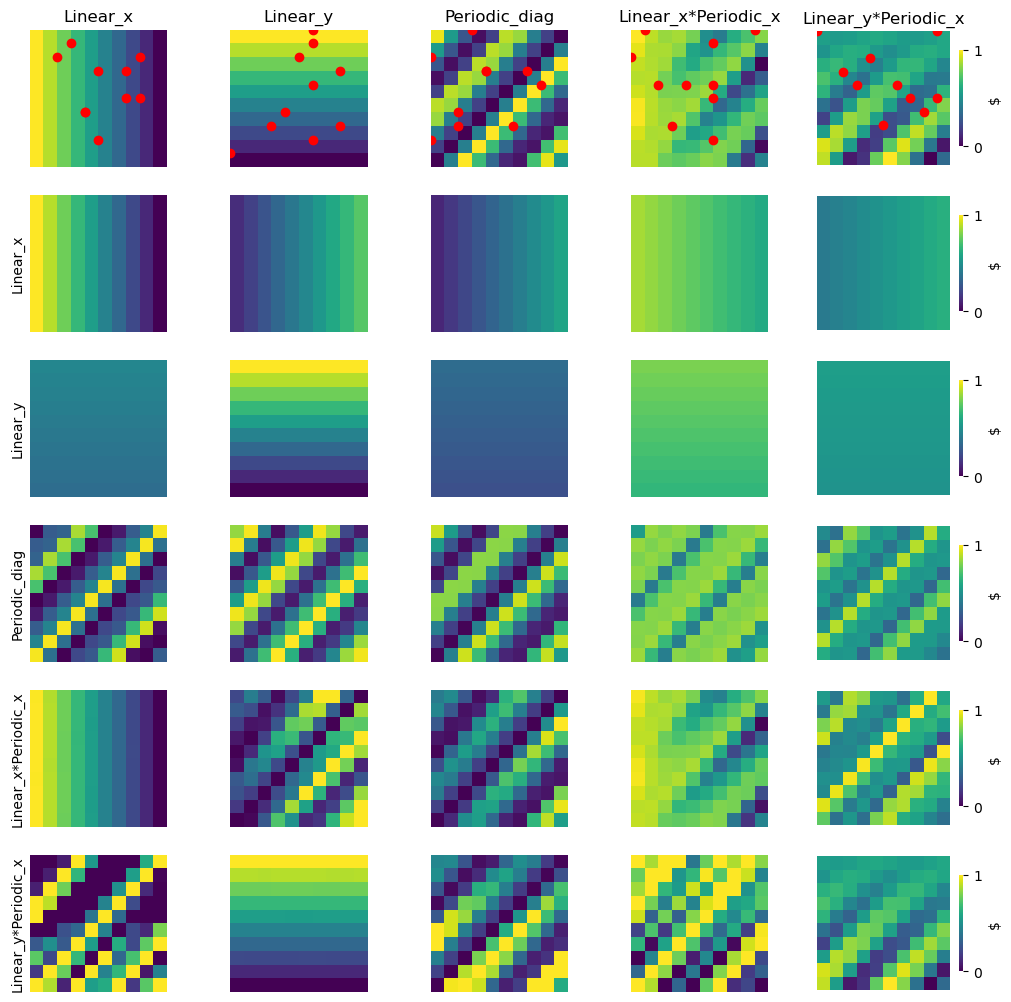

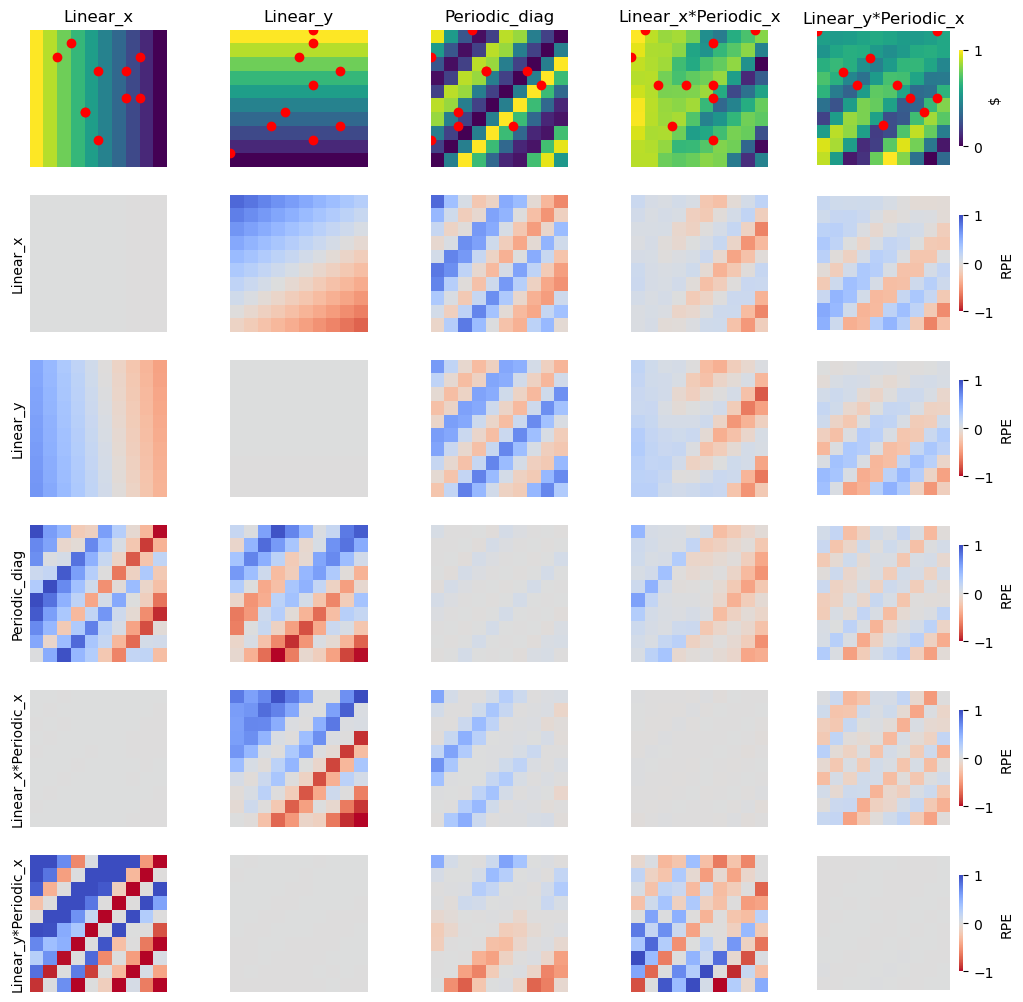

In [5]:
import GP
importlib.reload(GP)
from GP import *

import plotter
importlib.reload(plotter)
from plotter import *

### zero in on interesting combos

## inititialise the GP
N = 10
c = [1]
scale = [1]
theta = [0]
sigma_f = [1]
length_scale = [N/2.5]
# length_scale = np.linspace(1,10,5, dtype = int)
period = [4]
# period = np.linspace(1,10,10)
periodic_length_scale = [4]
# periodic_length_scale = [N/2.5]
# periodic_length_scale = np.linspace(1,10,10)
# periodic_theta = [0]
periodic_theta = [np.pi/4]
# GP_params = [c, scale, theta, sigma_f, length_scale, period, periodic_length_scale, periodic_theta]
param_combos = list(itertools.product(c, scale, theta, sigma_f, length_scale, period, periodic_length_scale, periodic_theta))
param_names = ['c', 'scale', 'theta', 'sigma_f', 'length_scale', 'period', 'periodic_length_scale', 'periodic_theta']

## init dict to store data
gp_dict = {
    'gen_kernel': [],
    'inf_kernel': [],
    'n_obs': [],
    'trial': [],
    'k_mll': [],
    'x_1': [],
    'x_2': [],
    'reward_1': [],
    'reward_2': [],
    'CP_1': [],
    'CP_2': [],
    'p(correct)': []
}
for param in param_names:
    gp_dict[param] = []

## loop through parameter initialisations
for pci in tqdm(range(len(param_combos))):
    params = param_combos[pci]

    ## define koi
    gp = GP_world(N, params)
    koi = [
        
        ## base kernels
        # gp.K_lin,
        gp.K_lin_x,
        gp.K_lin_y,
        # gp.K_rbf,
        # gp.K_rbf_x,
        # gp.K_rbf_y,
        gp.K_periodic_x,
        # gp.K_periodic_y,


        ## combos
        # gp.K_lin*gp.K_periodic_x,
        # gp.K_lin*gp.K_periodic_y,
        gp.K_lin_x*gp.K_periodic_x,
        gp.K_lin_y*gp.K_periodic_x,
        # gp.K_rbf_x*gp.K_periodic_x,
        # gp.K_rbf_y*gp.K_periodic_x,
        # gp.K_periodic_x*gp.K_periodic_y
    ]

    kernel_names = [
        ## base kernels
        # 'Linear',
        'Linear_x',
        'Linear_y',
        # 'RBF',
        # 'RBF_x',
        # 'RBF_y',
        # 'Periodic_x',
        # 'Periodic_y',
        'Periodic_diag',

        ## combos
        # 'Linear*Periodic_x',
        # 'Linear*Periodic_y',
        'Linear_x*Periodic_x',
        'Linear_y*Periodic_x',
        # 'RBF_x*Periodic_diag',
        # 'RBF_y*Periodic_diag',
        # 'Periodic_x*Periodic_y'
    ]


    ## init plots 
    n_k = len(koi)
    n_trials = 500
    if (pci == len(param_combos)-1):
        fig, axs = plt.subplots(n_k+1,n_k, figsize=(n_k*2.5,n_k*2.5))
        fig2, axs2 = plt.subplots(n_k+1,n_k, figsize=(n_k*2.5,n_k*2.5))



    ## loop through combos
    for kg, k_gen in enumerate(koi):
        k_gen_name = kernel_names[kg]
        gp.k_check(k_gen)

        ## loop through trials
        for t in range(n_trials):
        
            ## sample from combo kernel
            samples = gp.sample(k_gen)

            ## generate observations
            n_obs = 10
            all_obs = gp.gen_obs(samples, n_obs)
            
            ## for each trial, select two random points to choose between
            preds = gp.gen_preds(samples).squeeze()


            ## plot
            if (t == n_trials-1) & (pci == len(param_combos)-1):
                plot_r(samples, axs[0,kg], k_gen_name, cbar = kg==(len(koi)-1))
                plot_r(samples, axs2[0,kg], k_gen_name, cbar = kg==(len(koi)-1))
                plot_obs(all_obs, axs[0,kg], text=False)
                plot_obs(all_obs, axs2[0,kg], text=False)
            
            ## loop through inference kernels
            for ki, k_inf in enumerate(koi):
                k_inf_name = kernel_names[ki]

                ## incrementally increase the number of observations
                for o in range(n_obs):
                    obs = all_obs[:o+1]

                    ## calculate posterior of the points to compare, given the observations made so far
                    post_mean, post_cov = gp.post_pred(k_inf, obs, preds[:,0].astype(int))
                    # temp = 0.1
                    # choice_prob = softmax(post_mean/temp)
                    # choice_prob = gp.sigmoid(diff, tau)
                    choice_prob = [scipy.stats.norm.cdf(post_mean[0]-post_mean[1], 0, np.sum(np.diag(post_cov)))]
                    choice_prob.append(1-choice_prob[0])


                    ## compute log marginal likelihood under this kernel
                    ll = gp.likelihood(k_inf, obs)

                    ## save data
                    gp_dict['gen_kernel'].append(k_gen_name)
                    gp_dict['inf_kernel'].append(k_inf_name)
                    gp_dict['trial'].append(t)
                    gp_dict['k_mll'].append(ll)
                    gp_dict['n_obs'].append(o+1)
                    ## should also save the info about the observations somewhere
                    gp_dict['x_1'].append(preds[0,0])
                    gp_dict['x_2'].append(preds[1,0])
                    gp_dict['reward_1'].append(preds[0,-1])
                    gp_dict['reward_2'].append(preds[1,-1])
                    gp_dict['CP_1'].append(choice_prob[0])
                    gp_dict['CP_2'].append(choice_prob[1])
                    gp_dict['p(correct)'].append(choice_prob[np.argmax(preds[:,-1])])

                    ## save params
                    for param in param_names:
                        gp_dict[param].append(params[param_names.index(param)])
                
                ## plot the full posterior distribution once all observations have been made
                full_post_mean, _ = gp.post_pred(k_inf, obs)
                if (t == n_trials-1) & (pci == len(param_combos)-1):
                    plot_r(full_post_mean.reshape(N,N), axs[ki+1,kg], cbar = kg==(len(koi)-1))
                    RPE = samples-full_post_mean.reshape(N,N)
                    plot_RPE(RPE, axs2[ki+1,kg], cbar = (kg==(len(koi)-1)))
            

        ## loop through rows and add y-axis to the leftmost column
        if (t == n_trials-1) & (pci == len(param_combos)-1):
            for i in range(n_k):
                axs[i+1,0].set_ylabel(kernel_names[i])
                axs2[i+1,0].set_ylabel(kernel_names[i])

    ## convert ll_dict to df
    df_gp = pd.DataFrame(gp_dict)

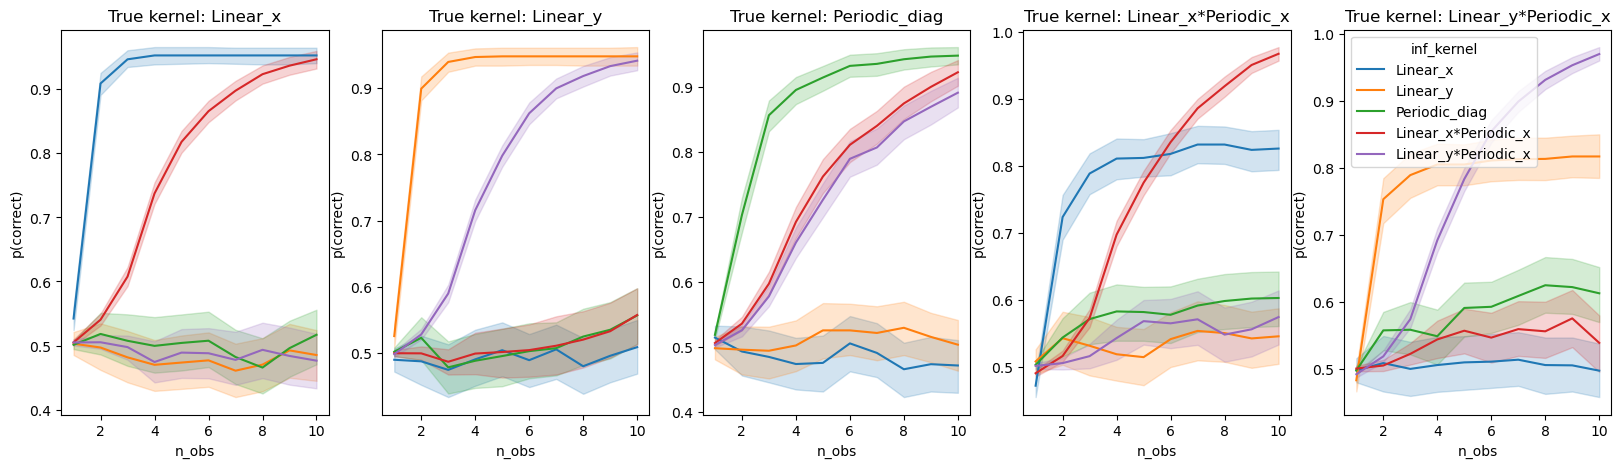

In [6]:
## plot accuracy as a function of number of observations

# param_of_interest = scale.copy()
# param_of_interest = length_scale.copy()
# param_of_interest = period.copy()
param_of_interest = periodic_length_scale.copy()
for p in periodic_length_scale:
    data_tmp = df_gp.loc[df_gp['periodic_length_scale']==p]
    fig, axs = plt.subplots(1, n_k, figsize=(4*n_k, 5))
    for gki, gen_k in enumerate(data_tmp['gen_kernel'].unique()):
        sns.lineplot(data = data_tmp.loc[data_tmp['gen_kernel']==gen_k], x = 'n_obs', y = 'p(correct)', hue = 'inf_kernel', ax = axs[gki], legend = gki==n_k-1)
        axs[gki].set_title('True kernel: '+gen_k)
    # plt.suptitle((p))

## plot confusion matrix
# plt.figure(figsize = (10,10))
# data = df_gp.loc[df_gp['n_obs']==n_obs]
# conf_mat = data.pivot_table(index = 'inf_kernel', columns = 'gen_kernel', values = 'p(correct)', aggfunc = 'mean')
# sns.heatmap(conf_mat, annot = True, square = True, cmap = 'coolwarm')
# plt.ylabel('inf_k')
# plt.xlabel('gen_k')
# conf_mat


Text(0, 0.5, 'log marginal likelihood')

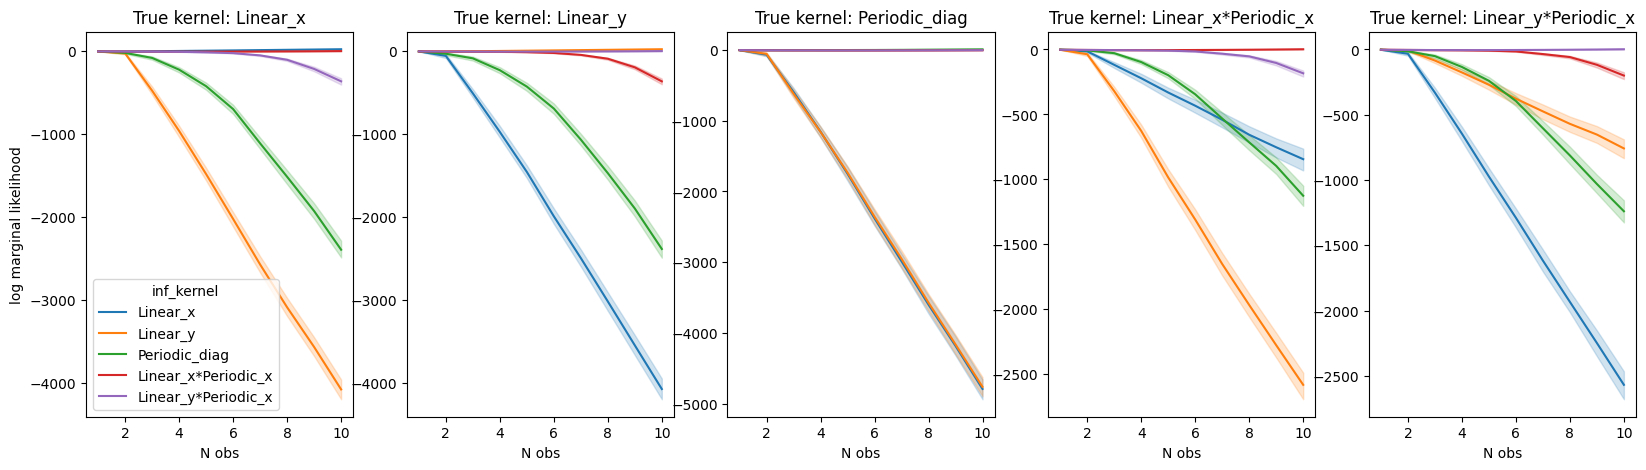

In [6]:
# plt.figure()
# sns.barplot(data=df_gp, x='gen_kernel', y='ll', hue='inf_kernel')

fig, axs = plt.subplots(1,n_k, figsize=(20,5))
for i in range(n_k):
    sns.lineplot(data = df_gp.loc[df_gp['gen_kernel'] == kernel_names[i]], x = 'n_obs', y = 'k_mll', hue = 'inf_kernel', ax = axs[i], legend=i==0, )
    axs[i].set_title('True kernel: '+kernel_names[i])
    axs[i].set_xlabel('N obs')
    axs[i].set_ylabel('')
    # axs[i].set_ylim(-100,25)
axs[0].set_ylabel('log marginal likelihood')
# axs[-1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

- for the same true R distr, generate predictions under each kernel
- identify the points that are maximally diagnostic?